In [207]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling


In [155]:
#tf.keras.utils.image_dataset_from_directory??

In [208]:
trainData = tf.keras.utils.image_dataset_from_directory(
    'trainData',
    image_size = (224,224),
    batch_size = 32)
#### Uncomment below after valData is uploaded
valData = tf.keras.utils.image_dataset_from_directory(
    'valData',
    image_size = (224,224),
    batch_size = 32)


Found 11332 files belonging to 3 classes.
Found 4773 files belonging to 3 classes.


In [209]:
trainData = trainData.map(lambda x, y: (x/255, y))
valData = valData.map(lambda x,y: (x/255, y))


In [210]:
# Rerun this to get a new batch
data_iterator = trainData.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

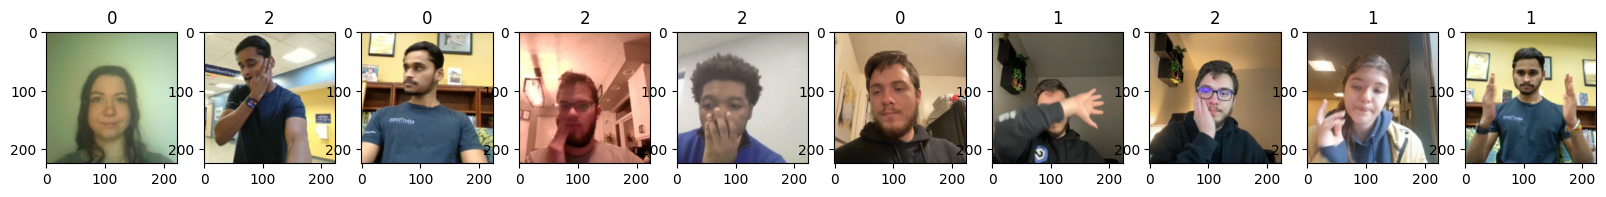

In [211]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [212]:
# Rerun this to get a new batch
val_data_iterator = valData.as_numpy_iterator()
val_batch = val_data_iterator.next()
val_batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

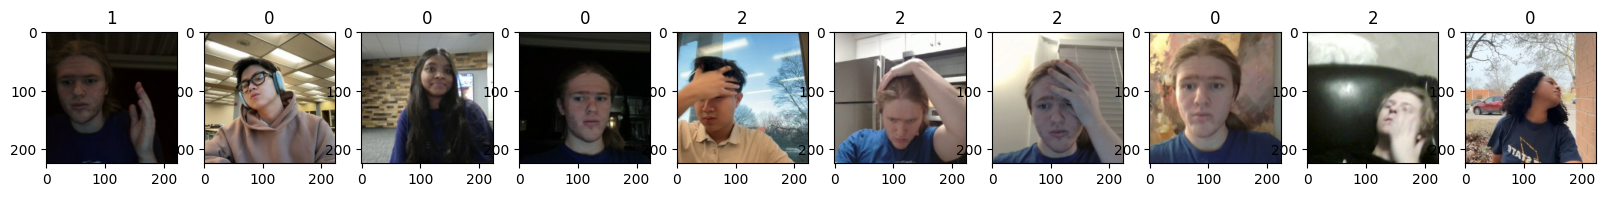

In [213]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(val_batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(val_batch[1][idx])

In [193]:
cnn = Sequential()

# Baseline architecture

In [214]:
cnn = Sequential()

cnn.add(Conv2D(32,(3,3),activation='relu', input_shape=(224,224,3)))
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

cnn.add(Flatten())

cnn.add(Dense(128,activation='relu'))
cnn.add(Dense(3,activation='softmax'))

In [215]:
cnn.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [217]:
logdir = 'logs'

In [ ]:
tensorboard_callback_base = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [221]:
hist = cnn.fit(trainData, epochs = 10, validation_data = valData, callbacks=[tensorboard_callback_base])  

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1946s 5s/step - accuracy: 0.8054 - loss: 0.4940 - val_accuracy: 0.4035 - val_loss: 1.5513
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 2867s 8s/step - accuracy: 0.9696 - loss: 0.1310 - val_accuracy: 0.4125 - val_loss: 1.8782
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 978s 3s/step - accuracy: 0.9918 - loss: 0.0508 - val_accuracy: 0.4029 - val_loss: 2.3916
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 973s 3s/step - accuracy: 0.9967 - loss: 0.0256 - val_accuracy: 0.4163 - val_loss: 2.5622
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 956s 3s/step - accuracy: 0.9970 - loss: 0.0197 - val_accuracy: 0.3878 - val_loss: 2.6555
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 3934s 11s/step - accuracy: 0.9989 - loss: 0.0094 - val_accuracy: 0.3995 - val_loss: 3.1884
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 862s 2s/step - accuracy: 0.9990 - loss: 0.0072 - val_accuracy: 0.4098 - val_loss: 2.8978
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1496s 4s/step - accuracy: 0.9988 - loss: 0.0068 - val

# Final Architecture
    - very light augmentation; flip, rotate, zoom
    - dropout rate = 0.3 & 0.5 after dense
    - activation - relu and softmax
    - learning rate = 0.0001

In [194]:
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.05))
cnn.add(RandomZoom(0.05))

# Block 1
cnn.add(Conv2D(32,(3,3),activation='relu', input_shape=(224,224,3)))
cnn.add(MaxPooling2D())

# Block 2
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

# Block 3
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

cnn.add(Dropout(0.3))   

cnn.add(Flatten())

cnn.add(Dense(64,activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(3,activation='softmax'))

c:\Users\emman\miniconda3\envs\touch_model\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [196]:
cnn.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [185]:
#cnn.summary()

In [197]:
logdir = 'logs'

In [198]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [199]:
hist = cnn.fit(trainData, epochs = 10, validation_data = valData, callbacks=[tensorboard_callback])  

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 258s 714ms/step - accuracy: 0.4184 - loss: 1.0534 - val_accuracy: 0.4536 - val_loss: 1.1791
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 313s 882ms/step - accuracy: 0.5797 - loss: 0.8724 - val_accuracy: 0.4287 - val_loss: 1.2617
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.6761 - loss: 0.7168 - val_accuracy: 0.4373 - val_loss: 1.5177
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.7356 - loss: 0.6022 - val_accuracy: 0.4117 - val_loss: 1.5533
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.7795 - loss: 0.5200 - val_accuracy: 0.4027 - val_loss: 1.9746
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.8073 - loss: 0.4644 - val_accuracy: 0.4006 - val_loss: 2.1919
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.8228 - loss: 0.4254 - val_accuracy: 0.4012 - val_loss: 2.1860
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.8378 - loss: 0.3882 - va

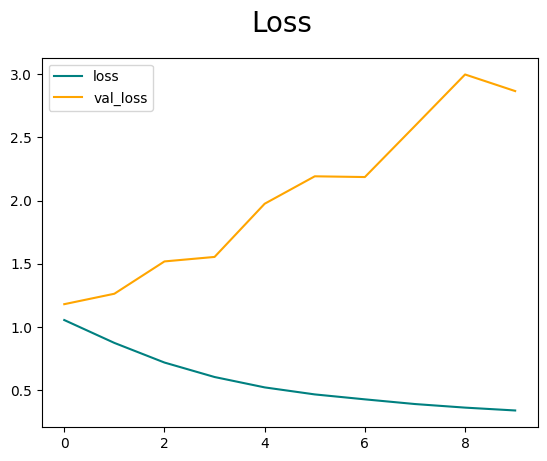

In [200]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color='orange', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc="upper left")
plt.show()

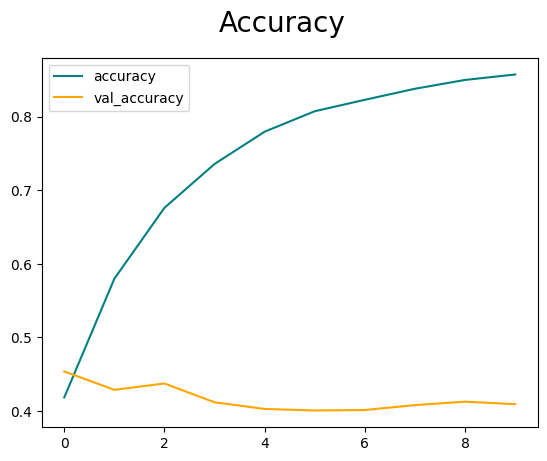

In [202]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 20)
plt.legend(loc="upper left")
plt.show()

# Saving the model

In [203]:
from tensorflow.keras.models import load_model

In [204]:
import os

In [205]:
cnn.save(os.path.join('models', 'touchmodel.h5'))

In [206]:
new_model = load_model(os.path.join('models', 'touchmodel.h5'))